# Features Overview

This overview demonstrates the basic capabilities of `eodag` in a simple worflow, whose steps are introduced in more details in the following pages.

The workflow consists of the following steps:

1. [Configure](#Configure): `eodag` is configured to use the provider *cop_dataspace* (registering to *cop_dataspace* is required to download the products, see [how to register to a provider](../providers.rst))
2. [Search](#Search): *Sentinel 2 Level-1C* products (i.e. images) are searched for over an area in France in March 2021.
3. [Crunch](#Crunch): Two dedicated filters - that we call *crunchers* - provided by `eodag`  are used to select products with a cloud cover less than 30% and covering the city of Toulouse (France).
4. [Serialize](#Serialize): Save the filtered products as a GeoJSON file.
4. [Download](#Download): The products are downloaded.
5. [Post-process](#Post-process): [eodag-cube](https://github.com/CS-SI/eodag-cube) is an external package that is used to access a product's data, it is going to be used to calculate the NDVI of a product.

## Configure

Let us first create a workspace directory to save products downloaded during this workflow.

In [1]:
import os

workspace = 'eodag_workspace_overview'
if not os.path.isdir(workspace):
    os.mkdir(workspace)

Now we will configure `eodag` to be able to download using *cop_dataspace*. For that we need to fill our credentials:

* in the user configuration file `~/.config/eodag/eodag.yml`:

```yaml
cop_dataspace:
    priority: # Lower value means lower priority (Default: 1)
    search:  # Search parameters configuration
    download:
        extract:  # whether to extract the downloaded products (true or false, Default: true).
        output_dir: # where to store downloaded products.
        dl_url_params:  # additional parameters to pass over to the download url as an url parameter
        delete_archive: # whether to delete the downloaded archives (true or false, Default: true).
    auth:
        credentials:
            username: PLEASE_CHANGE_ME
            password: PLEASE_CHANGE_ME
```

* or using environment variables: (we also set `output_dir`, the directory where to store downloaded products)

In [2]:
# os.environ["EODAG__COP_DATASPACE__AUTH__CREDENTIALS__USERNAME"] = "PLEASE_CHANGE_ME"
# os.environ["EODAG__COP_DATASPACE__AUTH__CREDENTIALS__PASSWORD"] = "PLEASE_CHANGE_ME"
os.environ["EODAG__COP_DATASPACE__DOWNLOAD__OUTPUT_DIR"] = os.path.abspath(workspace)

Logging is then activated with the [setup_logging()](../api_reference/utils.rst#eodag.utils.logging.setup_logging) method. It's a useful way to see what `eodag` does under the hood, e.g. requesting the provider, adapting the response. It's also useful to detect when things go wrong, and, if relevant, create an [issue on GitHub](https://github.com/CS-SI/eodag/issues) with the log messages.

In [6]:
from eodag import setup_logging
setup_logging(2)  # 3 for even more information

The next object to import, and this is certainly one of the most important objects provided by `eodag`, is the [EODataAccessGateway](../api_reference/core.rst#eodag.api.core.EODataAccessGateway) class. The creation of a single instance of this class is enough in a workflow, it is going to take care of configuring the providers, exposing the products configured off-the-shelf by `eodag`, and many more things.

In [7]:
from eodag import EODataAccessGateway
dag = EODataAccessGateway()

2026-03-26 18:08:49,052 eodag.provider                   [INFO    ] Loading user configuration from: /home/sbrunato/.config/eodag/eodag.yml
2026-03-26 18:08:49,076 eodag.core                       [INFO    ] Locations configuration loaded from /home/sbrunato/.config/eodag/locations.yml


`eodag` stores an internal catalog of products it makes easily accessible. *Sentinel 2 Level-1C* products are designated with the identifier *S2_MSI_L1C*. It's possible to check that it's made available by *cop_dataspace* with the method [list_collections()](../api_reference/core.rst#eodag.api.core.EODataAccessGateway.list_collections) which returns a list of [Collection](../api_reference/collection.rst#eodag.api.collection.Collection) instances, each one of them containing general metadata (`eodag`'s collection id, platform, sensor type, etc.).

In [8]:
dag.list_collections("cop_dataspace")

id:,"'S1_AUX_GNSSRD',"
title:,"'SENTINEL1 Auxiliary Product',"
description:,"'The Auxiliary (AUX) product contains the precise orbit ephemerides and the GNSS-Raw Data (GNSSRD) data. The precise orbit ephemerides are provided as a text file in the format of the International GNSS Service (IGS). The GNSS-Raw Data (GNSSRD) data is provided as a binary file in a specific format. SAFE formatted product, see https://sentinel.esa.int/web/sentinel/user-guides/sentinel-1-sar/data-formats/safe-specification ',"
extent:,"{ 'spatial': { 'bbox': [[-180.0 , -90.0 , 180.0 , 90.0 ] ] } , 'temporal': { 'interval': [[2014-04-06 00:00:00+00:00 , None ] ] } },"
keywords:,"['SAR' , 'SENTINEL' , 'SENTINEL1' , 'S1' , 'S1A' , 'S1B' , 'S1C' , 'AUX' , 'GNSSRD' , 'SAFE' ],"
license:,"'other',"
providers:,"[{ 'name': 'European Space Agency (ESA)' , 'roles': ['producer' , 'processor' , 'licensor' ] , 'url': 'https://earth.esa.int' } ],"
constellation:,"'SENTINEL1',"
instruments:,"['SAR' ],"
platform:,"'S1A,S1B,S1C',"
processing:level:,"'AUX',"


The method [set_preferred_provider()](../api_reference/core.rst#eodag.api.core.EODataAccessGateway.set_preferred_provider) allows to declare *cop_dataspace* as the preferred provider, which means that `eodag` will look for products with this provider first (all the providers are pre-configured).

In [10]:
dag.set_preferred_provider("cop_dataspace")

## Search

The [EODataAccessGateway](../api_reference/core.rst#eodag.api.core.EODataAccessGateway) class provides three search methods which have a similar signature but behave in different ways:

[search()](../api_reference/core.rst#eodag.api.core.EODataAccessGateway.search) returns a [SearchResult](../api_reference/searchresult.rst#eodag.api.search_result.SearchResult) that stores the products obtained from the first page with a given maximum **number of items per page** (default: `limit=20`). The attribute [SearchResult.number_matched](../api_reference/searchresult.rst#eodag.api.search_result.SearchResult) optionally stores the **estimated** total number of products matching the search criteria.

<div class="alert alert-info">

Note

[search()](../api_reference/core.rst#eodag.api.core.EODataAccessGateway.search) returns a *paginated result*. Pagination is the act of serving the result of a search page by page, each page contaning a maximum number of items. This is ubiquitous among search engines, e.g. a Google search displays in the browser 10 results per page. Pagination is built deep into the implementation of `eodag` since most providers return a paginated result.

</div>

<div class="alert alert-info">

Note

A search made with the [search()](../api_reference/core.rst#eodag.api.core.EODataAccessGateway.search) method with its default parameter often ends up with a [SearchResult](../api_reference/searchresult.rst#eodag.api.search_result.SearchResult) containing 20 products and a significantly greater estimated total number of products available. The parameter `limit` can be set to a higher value, or, the [search_all()](../api_reference/core.rst#eodag.api.core.EODataAccessGateway.search_all) method can be used instead.

</div>

<div class="alert alert-warning">

Warning

The [SearchResult.number_matched](../api_reference/searchresult.rst#eodag.api.search_result.SearchResult) property is the **estimated** total number of products matching the search criteria, since, unfortunately, all the providers do not return the **exact** total number.

</div>

[search_all()](../api_reference/core.rst#eodag.api.core.EODataAccessGateway.search_all) returns a [SearchResult](../api_reference/searchresult.rst#eodag.api.search_result.SearchResult) that contains **all** the products matching the search criteria. It takes the pain away from thinking about pagination.

[SearchResult.next_page()](../api_reference/searchresult.rst#eodag.api.search_result.SearchResult.next_page) is an iterator that returns a [SearchResult](../api_reference/searchresult.rst#eodag.api.search_result.SearchResult) page per page.

To get the *S2_MSI_L1C* products looked for, [search()](../api_reference/core.rst#eodag.api.core.EODataAccessGateway.search) is used first as it's handy to obtain some products and inspect them. Then [search_all()](../api_reference/core.rst#eodag.api.core.EODataAccessGateway.search_all) is used to make all the products offered by *cop_dataspace* are collected.

In [11]:
search_criteria = {
    "collection": "S2_MSI_L1C",
    "start": "2021-06-01",
    "end": "2021-06-30",
    "geom": {"lonmin": 1, "latmin": 43, "lonmax": 2, "latmax": 44},
    "count": True
}

The search criteria in this example consists of:

* `collection`: `eodag`'s collection
* `start` and `end`: the start and end sensing datetimes (UTC)
* `geom`: the region of interest, which can be defined in different ways (`list`, `dict`, WKT string, `shapely.geometry`).
* `count`: whether to retrieve the estimated total number of results or not (default is `False`)

In [12]:
products_first_page = dag.search(**search_criteria)
products_first_page

2026-03-26 18:10:46,065 eodag.core                       [INFO    ] Searching on provider cop_dataspace
2026-03-26 18:10:46,081 eodag.search.base                [INFO    ] cop_dataspace is configured with default sorting by 'start_datetime' in ascending order
2026-03-26 18:10:46,084 eodag.search.qssearch            [INFO    ] Sending search request: https://catalogue.dataspace.copernicus.eu/odata/v1/Products?$filter=Collection/Name%20eq%20%27SENTINEL-2%27%20and%20OData.CSC.Intersects%28area=geography%27SRID=4326%3BPOLYGON%20%28%281.0000%2043.0000%2C%201.0000%2044.0000%2C%202.0000%2044.0000%2C%202.0000%2043.0000%2C%201.0000%2043.0000%29%29%27%29%20and%20Attributes/OData.CSC.StringAttribute/any%28att:att/Name%20eq%20%27productType%27%20and%20att/OData.CSC.StringAttribute/Value%20eq%20%27S2MSI1C%27%29%20and%20ContentDate/Start%20lt%202021-06-30T00:00:00.000Z%20and%20ContentDate/End%20gt%202021-06-01T00:00:00.000Z&$orderby=ContentDate/Start%20asc&$count=True&$top=20&$skip=0&$expand=Attribu

SearchResult([EOProduct(id=S2A_MSIL1C_20210601T104021_N0500_R008_T31TCH_20230320T022849, provider=cop_dataspace),
              EOProduct(id=S2A_MSIL1C_20210601T104021_N0500_R008_T31TDJ_20230320T022849, provider=cop_dataspace),
              EOProduct(id=S2A_MSIL1C_20210601T104021_N0500_R008_T31TCJ_20230320T022849, provider=cop_dataspace),
              EOProduct(id=S2A_MSIL1C_20210601T104021_N0500_R008_T31TDH_20230320T022849, provider=cop_dataspace),
              EOProduct(id=S2A_MSIL1C_20210604T105031_N0500_R051_T31TCJ_20230312T163810, provider=cop_dataspace),
              EOProduct(id=S2A_MSIL1C_20210604T105031_N0500_R051_T31TDH_20230312T163810, provider=cop_dataspace),
              EOProduct(id=S2A_MSIL1C_20210604T105031_N0500_R051_T31TCH_20230312T163810, provider=cop_dataspace),
              EOProduct(id=S2A_MSIL1C_20210604T105031_N0500_R051_T31TDJ_20230312T163810, provider=cop_dataspace),
              EOProduct(id=S2B_MSIL1C_20210606T103629_N0500_R008_T31TCH_20230320T132557, provider=cop_dataspace),
              EOProduct(id=S2B_MSIL1C_20210606T103629_N0500_R008_T31TDH_20230320T132557, provider=cop_dataspace),
              EOProduct(id=S2B_MSIL1C_20210606T103629_N0500_R008_T31TCJ_20230320T132557, provider=cop_dataspace),
              EOProduct(id=S2B_MSIL1C_20210606T103629_N0500_R008_T31TDJ_20230320T132557, provider=cop_dataspace),
              EOProduct(id=S2B_MSIL1C_20210609T104619_N0500_R051_T31TDJ_20230314T070018, provider=cop_dataspace),
              EOProduct(id=S2B_MSIL1C_20210609T104619_N0500_R051_T31TCH_20230314T070018, provider=cop_dataspace),
              EOProduct(id=S2B_MSIL1C_20210609T104619_N0500_R051_T31TDH_20230314T070018, provider=cop_dataspace),
              EOProduct(id=S2B_MSIL1C_20210609T104619_N0500_R051_T31TCJ_20230314T070018, provider=cop_dataspace),
              EOProduct(id=S2A_MSIL1C_20210611T104021_N0500_R008_T31TDJ_20230315T081837, provider=cop_dataspace),
              EOProduct(id=S2A_MSIL1C_20210611T104021_N0500_R008_T31TCH_20230315T081837, provider=cop_dataspace),
              EOProduct(id=S2A_MSIL1C_20210611T104021_N0500_R008_T31TCJ_20230315T081837, provider=cop_dataspace),
              EOProduct(id=S2A_MSIL1C_20210611T104021_N0500_R008_T31TDH_20230315T081837, provider=cop_dataspace)])

The estimated total number of products matching the search criteria is stored in the `number_matched` attribute (set to `None` if `count` is disabled or not available).

In [13]:
print(f"Got {len(products_first_page)} products and an estimated total number of {products_first_page.number_matched} products.")

Got 20 products and an estimated total number of 52 products.


A [SearchResult](../api_reference/searchresult.rst#eodag.api.search_result.SearchResult) contains a number of [EOProduct](../api_reference/eoproduct.rst#eodag.api.product._product.EOProduct). Each one of them has a `properties` attribute that is a dictionary storing the product's metadata.

In [14]:
one_product = products_first_page[0]
one_product

EOProduct(id=S2A_MSIL1C_20210601T104021_N0500_R008_T31TCH_20230320T022849, provider=cop_dataspace)

A product also has a `location` attribute. After being searched, it is equal to the *remote location* of the product, that will be used later by `eodag` to download it.

In [15]:
one_product.location

'https://catalogue.dataspace.copernicus.eu/odata/v1/Products(6ca0653f-78e9-4146-a8a7-19e2ad8df47e)/$value'

All the products are now obtained from *cop_dataspace*.

In [16]:
all_products = dag.search_all(**search_criteria)

2026-03-26 18:11:06,133 eodag.core                       [INFO    ] Searching on provider cop_dataspace
2026-03-26 18:11:06,151 eodag.search.base                [INFO    ] cop_dataspace is configured with default sorting by 'start_datetime' in ascending order
2026-03-26 18:11:06,152 eodag.search.qssearch            [INFO    ] Sending search request: https://catalogue.dataspace.copernicus.eu/odata/v1/Products?$filter=Collection/Name%20eq%20%27SENTINEL-2%27%20and%20OData.CSC.Intersects%28area=geography%27SRID=4326%3BPOLYGON%20%28%281.0000%2043.0000%2C%201.0000%2044.0000%2C%202.0000%2044.0000%2C%202.0000%2043.0000%2C%201.0000%2043.0000%29%29%27%29%20and%20Attributes/OData.CSC.StringAttribute/any%28att:att/Name%20eq%20%27productType%27%20and%20att/OData.CSC.StringAttribute/Value%20eq%20%27S2MSI1C%27%29%20and%20ContentDate/Start%20lt%202021-06-30T00:00:00.000Z%20and%20ContentDate/End%20gt%202021-06-01T00:00:00.000Z&$orderby=ContentDate/Start%20asc&$top=1000&$skip=0&$expand=Attributes&$expan

In [17]:
print(f"Got a total number of {len(all_products)} products.")

Got a total number of 52 products.


## Crunch

Crunching as defined in `eodag` is a way to filter the products contained in a [SearchResult](../api_reference/searchresult.rst#eodag.api.search_result.SearchResult) object. Several crunchers/filters are available (e.g. [FilterProperty](../plugins_reference/generated/eodag.plugins.crunch.filter_property.FilterProperty.rst#eodag.plugins.crunch.filter_property.FilterProperty) to filter products products according to one of their properties). They can be called by passing the cruncher object to [SearchResult.crunch()](../api_reference/searchresult.rst#eodag.api.search_result.SearchResult.crunch) or by running a dedicated method (e.g. [SearchResult.filter_property()](../api_reference/searchresult.rst#eodag.api.search_result.SearchResult.filter_property)).
The following example shows how to filter products to keep only those whose cloud cover is less than 30%.

In [18]:
filtered_products = all_products.filter_property(**{"eo:cloud_cover": 30, "operator": "lt"})

2026-03-26 18:11:19,965 eodag.crunch.property            [INFO    ] Finished filtering products. 17 resulting products


In [19]:
print(f"Got now {len(filtered_products)} products after filtering by cloud coverage.")

Got now 17 products after filtering by cloud coverage.


Now, we use another cruncher to filter products containing a given geometry (Toulouse, France). We will use these products in [Post-process](#Post-process).

In [20]:
toulouse_bbox=[1.435, 43.587, 1.458, 43.602]
filtered_products = filtered_products.filter_overlap(geometry=toulouse_bbox, contains=True)

2026-03-26 18:11:26,926 eodag.crunch.overlap             [INFO    ] Finished filtering products. 1 resulting products


In [21]:
print(f"Got now {len(filtered_products)} products after filtering by geometry.")

Got now 1 products after filtering by geometry.


## Serialize

The method [serialize()](../api_reference/core.rst#eodag.api.core.EODataAccessGateway.serialize) allows to save a [SearchResult](../api_reference/searchresult.rst#eodag.api.search_result.SearchResult) as a *GeoJSON* file.

In [22]:
filtered_prods_filepath = dag.serialize(filtered_products, filename=os.path.join(workspace, "filtered_products.geojson"))

This method can come in handy to save the state of a search and restore it later with [deserialize_and_register()](../api_reference/core.rst#eodag.api.core.EODataAccessGateway.deserialize_and_register).

In [23]:
restored_filtered_prods = dag.deserialize_and_register(filtered_prods_filepath)
restored_filtered_prods

SearchResult([EOProduct(id=S2B_MSIL1C_20210609T104619_N0500_R051_T31TCJ_20230314T070018, provider=cop_dataspace)])

## Download

Before downloading any product, it can be useful to have a quick look at them. EO products usually offer a *quicklook* image, a low resolution by-product of the original data. An `EOProduct` has a [get_quicklook](../api_reference/eoproduct.rst#eodag.api.product._product.EOProduct.get_quicklook) method that takes care of downloading the quicklook image and returns its path. `matplotlib` can be used here to display the images collected.

0.00B [00:00, ?B/s]

2026-03-26 18:11:44,037 eodag.product                    [INFO    ] Download recorded in /home/sbrunato/workspace/eodag/docs/getting_started_guide/eodag_workspace_overview/quicklooks/S2B_MSIL1C_20210609T104619_N0500_R051_T31TCJ_20230314T070018


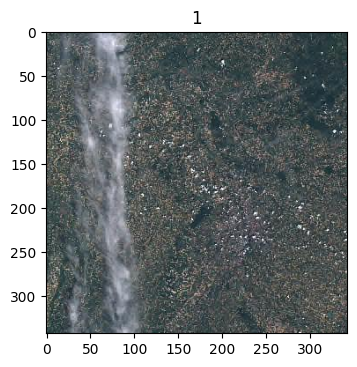

In [24]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

quicklooks_dir = os.path.join(workspace, "quicklooks")
if not os.path.isdir(quicklooks_dir):
    os.mkdir(quicklooks_dir)

fig = plt.figure(figsize=(10, 8))
for i, product in enumerate(filtered_products, start=1):

    # This line takes care of downloading the quicklook
    quicklook_path = product.get_quicklook(output_dir=quicklooks_dir)
    
    img = mpimg.imread(quicklook_path)
    ax = fig.add_subplot(1, 3, i)
    ax.set_title(i)
    plt.imshow(img)
plt.tight_layout()

[EOProduct](../api_reference/eoproduct.rst#eodag.api.product._product.EOProduct)s can either be downloaded individually with [download()](../api_reference/core.rst#eodag.api.core.EODataAccessGateway.download) or together with [download_all()](../api_reference/core.rst#eodag.api.core.EODataAccessGateway.download_all) from a [SearchResult](../api_reference/searchresult.rst#eodag.api.search_result.SearchResult). The last image is going to be downloaded, it is cloud-free and has no no-data pixel.

In [25]:
product_to_download = filtered_products[0]
product_path = dag.download(product_to_download)
product_path

0.00B [00:00, ?B/s]

2026-03-26 18:11:59,874 eodag.download.base              [INFO    ] Download url: https://catalogue.dataspace.copernicus.eu/odata/v1/Products(e50e9035-fd7c-403a-bebd-769a3a499954)/$value
2026-03-26 18:15:00,776 eodag.download.base              [INFO    ] Extraction activated
2026-03-26 18:15:01,536 eodag.download.base              [INFO    ] Deleting archive S2B_MSIL1C_20210609T104619_N0500_R051_T31TCJ_20230314T070018.zip
2026-03-26 18:15:01,574 eodag.product                    [INFO    ] Remote location of the product is still available through its 'remote_location' property: https://catalogue.dataspace.copernicus.eu/odata/v1/Products(e50e9035-fd7c-403a-bebd-769a3a499954)/$value


'/home/sbrunato/workspace/eodag/docs/getting_started_guide/eodag_workspace_overview/S2B_MSIL1C_20210609T104619_N0500_R051_T31TCJ_20230314T070018'

The `location` property of this product now points to a local path.

## Post-process

Now the product is downloaded, it can be post-processed with softwares such as [Sen2Cor](http://step.esa.int/main/snap-supported-plugins/sen2cor/) or [SNAP](http://step.esa.int/main/download/snap-download/).

At some point `eodag` had some capabilities to directly post-process a product, i.e. to access its data. These capabilities, which relied on [rasterio](https://rasterio.readthedocs.io/en/latest/), have been ported to the Python package [eodag-cube](https://github.com/CS-SI/eodag-cube) to avoid the heavy dependencies associated with  *GDAL* in particular. Installing this package is enough to benefit from its capabilities, it is going to extend [EOProduct](../api_reference/eoproduct.rst#eodag.api.product._product.EOProduct) with a `to_xarray()` method which returns a product's data as a `XarrayDict`, dictionnary of `xarray.Dataset`.

The capabilities of [eodag-cube](https://github.com/CS-SI/eodag-cube) are used hereafter to compute the NDVI of the downloaded product over a sub-extent of the original product (this is actually Toulouse, France).

<div class="alert alert-warning">

Warning

[eodag-cube](https://github.com/CS-SI/eodag-cube) needs to be installed to run correcly the following code.

</div>

In [26]:
import rasterio
import warnings

# mute rasterio warnings
warnings.filterwarnings("ignore", category=rasterio.errors.NotGeoreferencedWarning)

xd = product_to_download.to_xarray()
xd

0.00B [00:00, ?B/s]

2026-03-26 18:15:14,429 eodag.download.base              [INFO    ] Product already present on this platform. Identifier: /home/sbrunato/workspace/eodag/docs/getting_started_guide/eodag_workspace_overview/S2B_MSIL1C_20210609T104619_N0500_R051_T31TCJ_20230314T070018
2026-03-26 18:15:14,429 eodag.product                    [INFO    ] Remote location of the product is still available through its 'remote_location' property: https://catalogue.dataspace.copernicus.eu/odata/v1/Products(e50e9035-fd7c-403a-bebd-769a3a499954)/$value


XarrayDict (47)


In [27]:
VIR = xd["B04"].rio.clip_box(*toulouse_bbox, crs="EPSG:4326").rio.reproject(dst_crs="EPSG:4326")
NIR = xd["B08"].rio.clip_box(*toulouse_bbox, crs="EPSG:4326").rio.reproject(dst_crs="EPSG:4326")

NDVI = (NIR - VIR) / (NIR + VIR)
NDVI

<xarray.Dataset> Size: 126kB
Dimensions:      (x: 216, y: 142, band: 1)
Coordinates:
  * x            (x) float64 2kB 1.435 1.435 1.435 1.435 ... 1.458 1.458 1.458
  * y            (y) float64 1kB 43.6 43.6 43.6 43.6 ... 43.59 43.59 43.59 43.59
  * band         (band) int64 8B 1
    spatial_ref  int64 8B 0
Data variables:
    band_data    (band, y, x) float32 123kB nan nan nan nan ... nan nan nan nan
Attributes: (12/27)
    constellation:        SENTINEL-2
    datetime:             2021-06-09T10:46:19.024000Z
    end_datetime:         2021-06-09T10:46:19.024000Z
    id:                   S2B_MSIL1C_20210609T104619_N0500_R051_T31TCJ_202303...
    instruments:          ['MSI']
    platform:             S2B
    ...                   ...
    product:type:         S2MSI1C
    s2:datastrip_id:      S2B_OPER_MSI_L1C_DS_S2RP_20230314T070018_S20210609T...
    s2:datatake_id:       GS2B_20210609T104619_022242_N05.00
    s2:datatake_type:     INS-NOBS
    sat:absolute_orbit:   22242
    sat:relative_orbit:   51

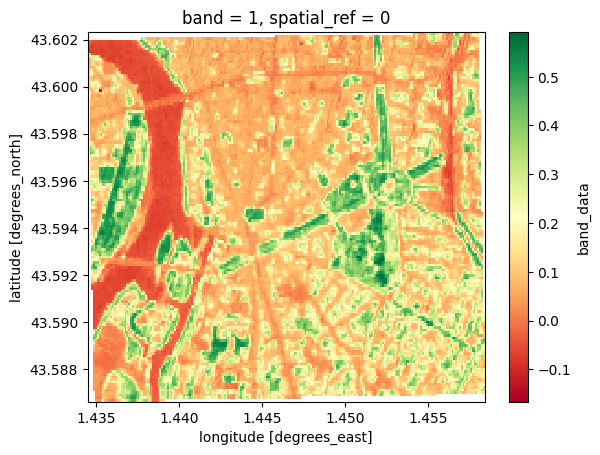

In [28]:
NDVI.band_data.plot(cmap="RdYlGn", center=False)